In [1]:
import sys
sys.path.append('../')

import numpy as np
import scipy.sparse as ssp
import matplotlib.pyplot as plt
import qutip as qt
import scqubits as scq
from matplotlib.colors import LogNorm
from tqdm import tqdm
from qutip.qip.operations import rz, cz_gate
import cmath
from sympy import symbols
import utils_2Q_gate_zp as ut
ut.set_fig_font() ### Set various sizes in plotting
import scipy as sp
from joblib import Parallel, delayed
import itertools
from qutip.qip.operations import rz, cz_gate, cnot, rx, hadamard_transform

In [3]:

infidelity_1A_n1_x0 =  [-1.218553561255794, -1.506173777297433, -1.7829506510118611, -1.9955258295414344,
 -2.144811539652661, -2.2767098791624427, -2.374008762511977, -2.465763316869905,
  -2.5380690654086093, -2.6186438889942916, -2.6627258552284365, -2.752001448376615,
   -2.8158647706090774, -2.861455079397341, -2.921200895509862, -2.9456122964147506,
    -3.007734877868249, -3.0591365235828936, -3.0758520864968175, -3.137400781441247,
     -3.1504017687092736, -3.209499286111117, -3.2357522306750033, -3.266276827910651]
drive_param_1A_n1_x0 = [[0.0356811167279671, 129.06093972107774, -0.014993641560590798],
[0.030207595014663878, 157.72256694633663, -0.01119661103087699],
[0.025723771227774726, 187.3062519442951, -0.008390214626025183],
[0.02192383875159001, 216.4349666784587, -0.006141212642547661],
[0.019127336398466345, 243.75945631549146, -0.004684781965804047],
[0.01676154997610405, 274.1621780578353, -0.0035874922511692497],
[0.01514248415523663, 300.81737359537004, -0.0029252168897050124],
[0.013728263687305266, 329.47915889120213, -0.0023999529515655316],
[0.01269273850867315, 354.75396935057705, -0.0020517560827051917],
[0.011619204139476433, 385.79128524262495, -0.0017143745985795655],
[0.011059453063762839, 404.3684348037451, -0.0015512847155149667],
[0.010013216641065952, 445.02904703845263, -0.0012729293966716737],
[0.009328561586387916, 476.8440232488472, -0.001102461135068622],
[0.008860036938024321, 501.3270970501612, -0.0009906463291670664],
[0.008284147130327458, 535.2483877609386, -0.0008680671179259747],
[0.008059337654731148, 549.927290940688, -0.0008193566559723808],
[0.007514612061037327, 589.1011113099828, -0.0007132044498445733],
[0.0070879478735599195, 623.8178108794979, -0.0006346058756059036],
[0.006952286541713816, 635.6373717491097, -0.0006100627049586971],
[0.006484139570970658, 680.9702188812981, -0.0005298209855642277],
[0.006389970143553594, 691.0258222204217, -0.0005154401685325549],
[0.005972108721229845, 738.6186117048629, -0.0004499611219015154],
[0.005796429706321363, 760.7601236757514, -0.00042315050660582387],
[0.0055985133232536784, 787.4607027868589, -0.0003940850775016602]]

Infidelity_1A_n1_x0 = [10**(infidelity_1A_n1_x0[i]) for i in range(len(infidelity_1A_n1_x0))]


In [4]:
fidelity_1A_n2 =  [-0.5757462905243769, -0.6590350075562903, -0.73704079451012, -0.7790017245096941, -0.862528207073771,
    -0.8740938436985237, -0.8969833623929822, -0.9006391092614822, -0.9381072565261013,
-0.9427361575465015, -0.9677205554579891, -0.9731891631015854, -0.9751448816452022,
-0.9734625183739277, -0.9802361501379904, -0.9813993223404719, -0.9843344634036226,
-0.9855667444276834, -0.9868910153725732, -0.9877769185725171, -0.9896989233387394,
-0.9906313571459064, -0.991654125358824, -0.9925243958043055]
drive_param_1A_n2 =  [[0.05238863410122971, 139.86517622777808, -0.42850030865200467],
[0.04405764253826877, 179.98887740241733, -0.2647629683041596],
[0.03277613761865712, 219.9699080015522, -0.14591610150863626],
[0.028177636867919565, 259.91791844523897, -0.1077176609322677],
[0.031942687041791804, 299.9165412734434, -0.13694364116604307],
    [0.0332313639990066, 314.2678685242008, -0.14801092169434035],
[0.02934378794382507, 352.46675006113395, -0.11547369582989139],
[0.03021932072214395, 365.8950832433146, -0.12238300378769831],
[0.032817520836418326, 405.219565860116, -0.15164537716118087],
[0.024053032196022516, 431.53071559392913, -0.08017821915419923],
[0.03052962819006067, 457.82881960054266, -0.13058701931090735],
[0.031666917796686574, 473.25677969207794, -0.13948718604576985],
[0.028604408895605594, 504.95495072163396, -0.11457407588265561],
[0.022739963052460607, 536.2559575157522, -0.0722919604503297],
[0.023813569339692454, 562.9493707304789, -0.08215729335933708],
[0.022094917675642672, 588.1017280206023, -0.06899821587870972],
[0.022395971800128853, 615.3609122984886, -0.07141835002373643],
[0.022426216278532033, 637.7235063709085, -0.0725395086801346],
[0.02170668627620164, 660.620582977675, -0.06780077209736603],
[0.01931299610639035, 690.7304747871749, -0.05281891658484349],
[0.018942352053426228, 719.9449983364569, -0.051190905049474184],
[0.01859203529743909, 739.7055880276047, -0.04948663767513835],
[0.018279703572100476, 769.2021161692436, -0.04823530652297854],
[0.01774289967298103, 799.4491349883092, -0.04557260100620912]]
Infidelity_1A_n2 = 1+np.array(fidelity_1A_n2)

In [5]:
fidelity_2A_n2 =  [-0.7714917613907989, -0.8388168947255139, -0.9060452654003808, -0.9372627847736613, -0.9535036362396184,
-0.9715823671862415, -0.9345256499375065, -0.983664356870632, -0.9582127908605853,
-0.9729720849252919, -0.9711513428668864, -0.9873659548488082, -0.9781061530449404,
-0.9988194348633705, -0.982753381329099, -0.996968221244242, -0.9989063512697636,
-0.986937904560226, -0.9991691785620114, -0.9995826266491271, -0.9927824545338467]
drive_param_2A_n2 =  [[0.03592439804808912, 0.08992276425481355, 139.90390641261996, -0.2489248988066275, -0.2258987206551441],
[0.032927928934059186, 0.09357592571085194, 179.96082482807037, -0.22887884734794495, -0.20319932312144656],
[0.026398572325558634, 0.06878357064985703, 219.63464472311918, -0.13632494186964345, -0.12132448555419928],
[0.025396926120527654, 0.05692762818813932, 259.4279296855925, -0.11761320848366591, -0.1094207630579454],
[0.029541218635507627, 0.05655586442413866, 285.0137729039848, -0.1517305215234565, -0.14525552032242572],
[0.026908216567162205, 0.047299105169493386, 326.08578362098825, -0.11966160135455217, -0.11479260579838152],
[0.019439045426886042, 0.04492031545055284, 351.5652742077028, -0.15179400946611138, -0.14454006288205845],
[0.01977740707555229, 0.06398631080790806, 370.9102914174842, -0.09664649552206277, -0.08135886823571417],
[0.02604846771013655, 0.09995625265003827, 403.9567564615782, -0.27868950657953406, -0.19628119452025936],
[0.018177082670069893, 0.04334064301323845, 431.3083849147486, -0.14552161770546493, -0.13905482894191276],
[0.022326347094830185, 0.0997524854900111, 457.6082283357523, -0.257070025403534, -0.17580229454912996],
[0.018345991024556897, 0.04566630227490296, 483.0066733483218, -0.1498114365260805, -0.1427578396331565],
[0.020451359078790546, 0.09966645817000591, 506.5202817134874, -0.24769133477958422, -0.16642750355836045],
[0.0170667592862181, 0.045169479612815186, 532.9329033924004, -0.06445703813383903, -0.05963717844427406],
[0.01866171905655222, 0.09987259272168897, 562.3742685973735, -0.23993786220176203, -0.15899947223048289],
[0.01620877206264524, 0.05196905335729312, 588.5728463721825, -0.1497165621457693, -0.14036753910052366],
[0.013997373957529667, 0.04503777692004904, 611.6649484780932, -0.05045225836137347, -0.043124590696284854],
[0.01732131908568567, 0.09987556420853061, 641.0230803077762, -0.23389839347397584, -0.14854739832889374],
[0.015054972763438403, 0.04709607154201853, 667.9053100074209, -0.13976547825979754, -0.13221959535844216],
[0.016269029133125813, 0.044466308079481494, 688.4008735983879, -0.14254216481082257, -0.13691485818842203],
[0.0157970278575909, 0.09981733679502063, 715.7205816651052, -0.2284435613332571, -0.14350402390177994]]
Infidelity_2A_n2 = 1+np.array(fidelity_2A_n2)

In [6]:
np.log10(1-0.999812)

-3.7258421507363986

In [7]:
1-10**(-4.59888820443905)

0.9999748167489146

In [8]:
fidelity_2A_n1_start =  [-0.9644328822919543, -0.9884631080815772, -0.996297267515029,
-0.9991820809881627, -0.9991066415329033,
-0.9996973090548857, -0.9997233623083254, -0.9986086347594743, -0.9994842951843985,
-0.9999600145127647, -0.9998124373489843, -0.9999047953449864, -0.9999164637966498,
-0.9998950100402642, -0.9999017019127789, -0.9999361328067407, -0.9999785962501356,
-0.9998919404101922, -0.9998556672752137, -0.9997631235703803, -0.9999130142025507,
-0.9998566431384768, -0.9998966515799659, -0.9999253758608232]
drive_param_2A_n1_start =  [[0.07557352380680618, 0.045406901210387846, 139.80121562950333, -0.03988304689581973, -0.0463514140425621],
[0.07262631867604984, 0.03998653589305963, 179.84466187159165, -0.03759725943039438, -0.042730473319776696],
[0.06603415954649548, 0.032313257221391674, 215.39818844027002, -0.028110942948351314, -0.03363993397033299],
[0.06561456119771665, 0.03256070030188406, 255.8568219747646, -0.03309632759894371, -0.03658041169233178],
[0.08214998234257803, 0.022990968193458108, 296.66484505688254, -0.023540986415900633, -0.037436621530911374],
[0.0754751709841197, 0.024475013338660225, 317.4485123699629, -0.02987912201182486, -0.03701554537424631],
[0.08382476280437687, 0.022136314047758274, 346.44487004688864, -0.027351130436972983, -0.03970968382979541],
[0.09229964280612983, 0.026601756554862972, 376.59966093024786, -0.010816171264945452, -0.033824786376229904],
[0.08305134439614023, 0.0263249315943987, 403.9988097743255, -0.01803758091532333, -0.02972465374945854],
[0.06489069860635269, 0.016290503464261363, 420.1249512139678, -0.015430544119623952, -0.02485317699266697],
[0.01967686443765512, 0.04672062083058919, 452.9362083255372, -0.032270808981640406, -0.026490447604241837],
[0.06469714750507521, 0.016164034894909862, 476.81056482314733, -0.020049380084144527, -0.026845197777496697],
[0.06831701388597096, 0.015752320438056522, 508.2167344167714, -0.021316509087653854, -0.028927534220335754],
[0.07765028823085302, 0.021993721743768353, 520.5407646948191, -0.01927521355853269, -0.0275170296797126],
[0.017293846547049567, 0.042548271961394254, 561.6287595730695, -0.028635636620811485, -0.024028598077006885],
[0.09093487452034041, 0.02050434300128, 568.2023850522946, -0.0200753636906556, -0.035462277297332916],
[0.017288875336996072, 0.05694441613632384, 613.2797198238103, -0.04614244258591799, -0.03778463600945826],
[0.015250695644491087, 0.05855151966102661, 622.9539601382995, -0.045619373824305386, -0.03428535536312615],
[0.09131534784539207, 0.02752032537828817, 649.9578905995049, -0.018293818030836784, -0.02581656743135016],
[0.0932693813934253, 0.023241347725666828, 670.3131891141076, -0.01704538638831417, -0.029206071452904887],
[0.019171822913529535, 0.0570750584282845, 698.8312637953481, -0.03617811304414885, -0.027688043381542727],
[0.013928621173231341, 0.055880972072264036, 741.6099220567236, -0.043422977436920335, -0.03416438480505566],
[0.08453172521659846, 0.022074545870554997, 750.5375033542462, -0.01736168654379744, -0.025203060201389245],
[0.01740130844874547, 0.061554059671197606, 775.622960768678, -0.04195679716076918, -0.03048281096024886]]
Infidelity_2A_n1_start = 1+np.array(fidelity_2A_n1_start)


In [9]:
fidelity_2A_n1_start =  [-0.9644328822919543, -0.9884631080815772, -0.996297267515029,
-0.9991820809881627, -0.9991066415329033,
-0.9996973090548857, -0.9997233623083254, -0.9986086347594743, -0.9994842951843985,
-0.9999600145127647, -0.9998124373489843, -0.9999047953449864, -0.9999164637966498,
-0.9998950100402642, -0.9999017019127789, -0.9999361328067407, -0.9999785962501356,
-0.9998919404101922, -0.9998556672752137, -0.9997631235703803, -0.9999130142025507,
-0.9998566431384768, -0.9998966515799659, -0.9999253758608232]
drive_param_2A_n1_start =  [[0.07557352380680618, 0.045406901210387846, 139.80121562950333, -0.03988304689581973, -0.0463514140425621],
[0.07262631867604984, 0.03998653589305963, 179.84466187159165, -0.03759725943039438, -0.042730473319776696],
[0.06603415954649548, 0.032313257221391674, 215.39818844027002, -0.028110942948351314, -0.03363993397033299],
[0.06561456119771665, 0.03256070030188406, 255.8568219747646, -0.03309632759894371, -0.03658041169233178],
[0.08214998234257803, 0.022990968193458108, 296.66484505688254, -0.023540986415900633, -0.037436621530911374],
[0.0754751709841197, 0.024475013338660225, 317.4485123699629, -0.02987912201182486, -0.03701554537424631],
[0.08382476280437687, 0.022136314047758274, 346.44487004688864, -0.027351130436972983, -0.03970968382979541],
[0.09229964280612983, 0.026601756554862972, 376.59966093024786, -0.010816171264945452, -0.033824786376229904],
[0.08305134439614023, 0.0263249315943987, 403.9988097743255, -0.01803758091532333, -0.02972465374945854],
[0.06489069860635269, 0.016290503464261363, 420.1249512139678, -0.015430544119623952, -0.02485317699266697],
[0.01967686443765512, 0.04672062083058919, 452.9362083255372, -0.032270808981640406, -0.026490447604241837],
[0.06469714750507521, 0.016164034894909862, 476.81056482314733, -0.020049380084144527, -0.026845197777496697],
[0.06831701388597096, 0.015752320438056522, 508.2167344167714, -0.021316509087653854, -0.028927534220335754],
[0.07765028823085302, 0.021993721743768353, 520.5407646948191, -0.01927521355853269, -0.0275170296797126],
[0.017293846547049567, 0.042548271961394254, 561.6287595730695, -0.028635636620811485, -0.024028598077006885],
[0.09093487452034041, 0.02050434300128, 568.2023850522946, -0.0200753636906556, -0.035462277297332916],
[0.017288875336996072, 0.05694441613632384, 613.2797198238103, -0.04614244258591799, -0.03778463600945826],
[0.015250695644491087, 0.05855151966102661, 622.9539601382995, -0.045619373824305386, -0.03428535536312615],
[0.09131534784539207, 0.02752032537828817, 649.9578905995049, -0.018293818030836784, -0.02581656743135016],
[0.0932693813934253, 0.023241347725666828, 670.3131891141076, -0.01704538638831417, -0.029206071452904887],
[0.019171822913529535, 0.0570750584282845, 698.8312637953481, -0.03617811304414885, -0.027688043381542727],
[0.013928621173231341, 0.055880972072264036, 741.6099220567236, -0.043422977436920335, -0.03416438480505566],
[0.08453172521659846, 0.022074545870554997, 750.5375033542462, -0.01736168654379744, -0.025203060201389245],
[0.01740130844874547, 0.061554059671197606, 775.622960768678, -0.04195679716076918, -0.03048281096024886]]
Infidelity_2A_n1_start = 1+np.array(fidelity_2A_n1_start)


In [10]:
1-10**(-6.3927642230565)

0.9999995952044058

In [11]:
np.log10(1-0.9999377891704537)

-4.206134007547116

In [12]:
fidelity_2A_n1 =  [-0.9644328822919543, -0.9884631080815772, -0.996297267515029, -0.9991820809881627,
-0.9994472566740707, -0.9996973236400599, -0.9997663792916935, -0.9998040552849281,
-0.9999456450542921, -0.999995930274163, -0.9999995952044058, -0.9999835210175945,

-0.9999820654493886, -0.9999880215580467, -0.9999913808128518, -0.9999818811826582,
-0.9999937482528842, -0.9999790841006808, -0.9999930545836826, -0.9999974028093327,
-0.9999903543110971, -0.9999855379284052]
drive_param_2A_n1 =  [[0.07557352380680618, 0.045406901210387846, 139.80121562950333, -0.03988304689581973, -0.0463514140425621],
[0.07262631867604984, 0.03998653589305963, 179.84466187159165, -0.03759725943039438, -0.042730473319776696],
[0.06603415954649548, 0.032313257221391674, 215.39818844027002, -0.028110942948351314, -0.03363993397033299],

[0.06561456119771665, 0.03256070030188406, 255.8568219747646, -0.03309632759894371, -0.03658041169233178],
[0.08714064673421647, 0.025542520009583278, 296.6600233615975, -0.03259309218149793, -0.044177706289487875],
[0.0754751709841197, 0.024475013338660225, 317.4491693384626, -0.029879122011824882, -0.03701554537424631],
[0.08324370068465164, 0.022301131204851707, 346.4414470805427, -0.028310692699608522, -0.039823276231414004],
[0.07668347457420832, 0.017500844024213, 376.60467839567855, -0.0099070794216432, -0.029941568948089782],


[0.08519997507149087, 0.028762603136169497, 404.00207461095397, -0.025975962691102063, -0.034013945266784036],
[0.07368360422310369, 0.01681222219061629, 420.13378612121545, -0.0164934651853555, -0.029706520480420585],


[0.07953654959206298, 0.021779220858655912, 452.90000022645984, -0.009208037275464275, -0.025201661422210253],
[0.07568862091479621, 0.016291640084021314, 476.8119987240192, -0.021136805705293683, -0.032355967301183036],

[0.08408417469411858, 0.01779387775567124, 508.2163529293701, -0.03165649565917509, -0.04121905705940017],
[0.07469277790707572, 0.02274032140874433, 520.5357386282718, -0.02019773719338336, -0.02666551307287962],
[0.019264889934327928, 0.04975548128597433, 561.6249700513596, -0.03830541862121366, -0.032699696606221844],
[0.09112374052604064, 0.020683296902494583, 568.2057962528512, -0.020451640951103262, -0.03572101637613608],
[0.015780792563004478, 0.057383626266418866, 622.9623387225525, -0.04495895780122579, -0.03502183216305868],

[0.08830803742547773, 0.01920923564468846, 649.9535876749549, -0.023110818772120408, -0.03506824244009106],
[0.021137703062404502, 0.0596716545446008, 698.8299531156171, -0.04097497299530319, -0.0332560047050199],
[0.013600010582849497, 0.05817024479693955, 741.6082284055336, -0.04545533195073465, -0.034308799299548796],
[0.09315876564104514, 0.021954508478920318, 750.5473945321047, -0.02844149257885838, -0.036749297300687815],
[0.01692433175847455, 0.05881211235569254, 775.6329379717887, -0.03800983197049337, -0.027132942666651484]]
Infidelity_2A_n1 = 1+np.array(fidelity_2A_n1)



In [13]:


fidelity_2A_n1_x0 =  [-0.9994472566740707, -0.9996973236400599, -0.9997663792916935, -0.9996742068964825,
-0.9995716823356157, -0.9999600145127647]
drive_param_2A_n1_x0 =  [[0.08714064673421647, 0.025542520009583278, 296.6600233615975, -0.03259309218149793, -0.044177706289487875],
[0.0754751709841197, 0.024475013338660225, 317.4491693384626, -0.029879122011824882, -0.03701554537424631],
[0.08324370068465164, 0.022301131204851707, 346.4414470805427, -0.028310692699608522, -0.039823276231414004],
[0.08698179118853329, 0.01862289651731184, 376.60742958769777, -0.010757615520897185, -0.037125126250818805],
[0.08380418139184594, 0.024324545005091736, 404.00063145574427, -0.0099407702414398, -0.027859217591996083],
[0.06489069860635269, 0.016290503464261363, 420.1249512139678, -0.015430544119623912, -0.02485317699266701]]
Infidelity_2A_n1_x0 = 1+np.array(fidelity_2A_n1_x0)



In [14]:
infidelity_2A_n1_logF =  [-3.942314336584087, -4.718362591435532, -4.206132202703002,
-4.525935929671652, -4.668448698332815, -4.564234014629579, -5.117115616446872,
-4.744344614020557, -5.081265399122827, -4.751779297631054]
drive_param_2A_n1_logF =  [[0.07747529750470104, 0.026101585292258162, 404.0085571288468, -0.017785120783845407, -0.02660757226781151],
[0.06643400044552562, 0.016461619607978907, 420.11890260507005, -0.015916930965465776, -0.025769811672114756],
[0.019847318426711474, 0.046438912710212575, 452.9435660271829, -0.03221106696480644, -0.026567623358587165],
[0.06785034932029498, 0.016269276480700874, 476.81174045247167, -0.02067777181374395, -0.028451694499975998],
[0.07884108641924287, 0.01647230548590152, 508.2247119494204, -0.025389092061560044, -0.0357042074700816],
[0.07791981705247558, 0.015158452016843106, 520.5461197203882, -0.019840244884824762, -0.033051153776950386],
[0.015706691057571547, 0.0413753738634257, 561.6301696131569, -0.026087589073304343, -0.02108801382602738],
[0.091159398877222, 0.02068700935010942, 568.2055488894404, -0.020480489066205566, -0.035750979470163334],
[0.015452359560352423, 0.05303361009346963, 622.9491104145947, -0.03932825219076282, -0.030911390268990938],
[0.08697361811486287, 0.023488171511987677, 649.9640081844852, -0.023372299283092503, -0.03096763251691995]]

Infidelity_2A_n1_logF = [10**(infidelity_2A_n1_logF[i]) for i in range(len(infidelity_2A_n1_logF))]

In [15]:
infidelity_2A_n1_x0_logF =  [-4.264760933713015, -5.390434846669082, -4.206134007547116, -4.783069609951213,
-4.746309501030947, -4.921599667345317, -5.0645336893590835, -4.7418701531650145,
-5.203998597582875, -4.679523457358143, -5.158301716962656, -5.585496166381358,
-5.015666749247687, -4.839769492811518]
drive_param_2A_n1_x0_logF =  [[0.08519997507149087, 0.028762603136169497, 404.00207461095397, -0.025975962691102063, -0.034013945266784036],
[0.07368360422310369, 0.01681222219061629, 420.13378612121545, -0.0164934651853555, -0.029706520480420585],
[0.019847538056258038, 0.04643890457429329, 452.94356604958097, -0.03221107458131659, -0.02656755643591971],
[0.07568862091479621, 0.016291640084021314, 476.8119987240192, -0.021136805705293683, -0.032355967301183036],
[0.08408417469411858, 0.01779387775567124, 508.2163529293701, -0.03165649565917509, -0.04121905705940017],
[0.07469277790707572, 0.02274032140874433, 520.5357386282718, -0.02019773719338336, -0.02666551307287962],
[0.019264889934327928, 0.04975548128597433, 561.6249700513596, -0.03830541862121366, -0.032699696606221844],
[0.09112374052604064, 0.020683296902494583, 568.2057962528512, -0.020451640951103262, -0.03572101637613608],
[0.015780792563004478, 0.057383626266418866, 622.9623387225525, -0.04495895780122579, -0.03502183216305868],
[0.08830803742547773, 0.01920923564468846, 649.9535876749549, -0.023110818772120408, -0.03506824244009106],
[0.021137703062404502, 0.0596716545446008, 698.8299531156171, -0.04097497299530319, -0.0332560047050199],
[0.013600010582849497, 0.05817024479693955, 741.6082284055336, -0.04545533195073465, -0.034308799299548796],
[0.09315876564104514, 0.021954508478920318, 750.5473945321047, -0.02844149257885838, -0.036749297300687815],
[0.01692433175847455, 0.05881211235569254, 775.6329379717887, -0.03800983197049337, -0.027132942666651484]]

Infidelity_2A_n1_x0_logF = [10**(infidelity_2A_n1_x0_logF[i]) for i in range(len(infidelity_2A_n1_x0_logF))]

In [52]:
fidelity_2A_n1_r2 =  [-3.3634564107469975, -4.1412470080459665, -4.113701731899588, -4.743476773238503, -4.957118759268152]
drive_param_2A_n1_r2 =  [[0.07830073076579484, 0.026863026615025726, 279.9999668380671, -0.031160109465253563, -0.03927095234589164],
[0.07601957910756506, 0.02504258843180761, 309.9999668866966, -0.030272682505848345, -0.03755469639929651],
[0.09150631840114574, 0.022780016816926225, 339.9999145642021, -0.029821737356828013, -0.04530933349733816],
[0.0818997141250141, 0.020776995821780754, 369.9999856598085, -0.026755200445700643, -0.03822141709100123],
[0.06517893233226774, 0.017060124583084493, 399.9999906572392, -0.01611114211193787, -0.025302012374410956]]
Infidelity_2A_n1_r2 = [10**(fidelity_2A_n1_r2[i]) for i in range(len(fidelity_2A_n1_r2))]


fidelity_14_2A_combine = [0.9644328822919543, 0.9884631080815772, 0.996297267515029, 0.9991820809881627,
 0.9995669444695412, 0.9999277641159935, 0.9999230341148969,
 0.9999819480872094, 0.9999889622325279, 0.999995930274163, 0.9999995952044058]
drive_param_14_2A_combine = [[0.07557352380680618, 0.045406901210387846, 139.80121562950333, -0.03988304689581973, -0.0463514140425621],
[0.07262631867604984, 0.03998653589305963, 179.84466187159165, -0.03759725943039438, -0.042730473319776696],
[0.06603415954649548, 0.032313257221391674, 215.39818844027002, -0.028110942948351314, -0.03363993397033299],
[0.06561456119771665, 0.03256070030188406, 255.8568219747646, -0.03309632759894371, -0.03658041169233178],
[0.07830073076579484, 0.026863026615025726, 279.9999668380671, -0.031160109465253563, -0.03927095234589164],
[0.07601957910756506, 0.02504258843180761, 309.9999668866966, -0.030272682505848345, -0.03755469639929651],
[0.09150631840114574, 0.022780016816926225, 339.9999145642021, -0.029821737356828013, -0.04530933349733816],
[0.0818997141250141, 0.020776995821780754, 369.9999856598085, -0.026755200445700643, -0.03822141709100123],
[0.06517893233226774, 0.017060124583084493, 399.9999906572392, -0.01611114211193787, -0.025302012374410956],
[0.07368360422310369, 0.01681222219061629, 420.13378612121545, -0.0164934651853555, -0.029706520480420585],
[0.07953654959206298, 0.021779220858655912, 452.90000022645984, -0.009208037275464275, -0.025201661422210253]]
Infidelity_14_2A_combine = 1-np.array(fidelity_14_2A_combine)


In [17]:
fidelity_2A_combine = [0.5184182997800467, 0.6759875129318533, 0.795766121576647,
0.86386278775011, 0.9416538406488264, 0.9381183577963004, 0.9570164489358659,
0.9553915401325936, 0.9533334277514843, 0.9757216392731017, 0.9840901447663579,
0.9927355824906225, 0.9955156136304992,0.996297267515029, 0.9991820809881627,
0.9995669444695412,0.9999277641159935, 0.9999230341148969, 0.9999819480872094,
0.9999889622325279,0.999995930274163, 0.9999995952044058,
]
drive_param_2A_combine = [
[0.13655477501019325, 0.10794615494328463, 19.99999999412964, -0.1373728419868848, -0.12647877284253578],
[0.13241611373174095, 0.11250934322800019, 32.857142851461, -0.17780126875378566, -0.16663004414450908],
[0.1346592242690052, 0.12763884958760502, 45.71428570811034, -0.2405578162252669, -0.22720278135901742],
[0.13642510901400648, 0.14177261808958422, 58.5714285652226, -0.29992146912676343, -0.2844545017345545],
[0.20968894214945819, 0.11375180331797835, 84.28571428275639, -0.2596106198879004, -0.27852722518057355],
[0.11526320444441393, 0.12481643898279215, 97.14285713751849, -0.22203452653045946, -0.20924903512889548],
[0.11880611014675484, 0.13399141225935418, 109.99999999436317, -0.258890225439262, -0.24473645588570242],
[0.20948133295077548, 0.08590173432174125, 122.85714285189243, -0.22463838412830428, -0.2845710761610976],
[0.0757304742236375, 0.04442869405857458, 135.7142857056725, -0.037887577634313885, -0.044916255039324185],
[0.20940123819257545, 0.07896208845110898, 148.5714285624567, -0.2394379869836075, -0.28492570540717854],
[0.20000268616944536, 0.07332735845639228, 161.42857142035075, -0.2298248001980925, -0.26676037126894997],
[0.09198336544909672, 0.0981689360664377, 174.2857142800867, -0.02431327060564875, -0.017670618989625908],
[0.08875362517793295, 0.03745505209768381, 199.99999999606837, -0.04283226869094012, -0.05232422288208745],
[0.06603415954649548, 0.032313257221391674, 215.39818844027002, -0.028110942948351314, -0.03363993397033299],
[0.06561456119771665, 0.03256070030188406, 255.8568219747646, -0.03309632759894371, -0.03658041169233178],
[0.07830073076579484, 0.026863026615025726, 279.9999668380671, -0.031160109465253563, -0.03927095234589164],
[0.07601957910756506, 0.02504258843180761, 309.9999668866966, -0.030272682505848345, -0.03755469639929651],
[0.09150631840114574, 0.022780016816926225, 339.9999145642021, -0.029821737356828013, -0.04530933349733816],
[0.0818997141250141, 0.020776995821780754, 369.9999856598085, -0.026755200445700643, -0.03822141709100123],
[0.06517893233226774, 0.017060124583084493, 399.9999906572392, -0.01611114211193787, -0.025302012374410956],
[0.07368360422310369, 0.01681222219061629, 420.13378612121545, -0.0164934651853555, -0.029706520480420585],
[0.07953654959206298, 0.021779220858655912, 452.90000022645984, -0.009208037275464275, -0.025201661422210253],

]
Infidelity_2A_combine = 1-np.array(fidelity_2A_combine)

In [18]:
fidelity_14_2A_tg20 =  [-0.3173300243343102, -0.48943825226162685, -0.6898722152758832, -0.8660231469067232, -0.7063805076066604,
-1.2339877262079575, -1.208438169592233, -1.3666977083454543, -1.3505827707649574, -1.330994097726927,
-1.6147806401378226, -1.7983337720514982, -2.1387992034726415, -1.9256884772977019, -2.3482969761588426]
drive_param_14_2A_tg20 =  [[0.13655477501019325, 0.10794615494328463, 19.99999999412964, -0.1373728419868848, -0.12647877284253578],
[0.13241611373174095, 0.11250934322800019, 32.857142851461, -0.17780126875378566, -0.16663004414450908],
[0.1346592242690052, 0.12763884958760502, 45.71428570811034, -0.2405578162252669, -0.22720278135901742],
[0.13642510901400648, 0.14177261808958422, 58.5714285652226, -0.29992146912676343, -0.2844545017345545],
[0.06097063806247123, 0.048159190961066606, 71.42857142574856, -0.028482617471912802, -0.027105932052997855],
[0.20968894214945819, 0.11375180331797835, 84.28571428275639, -0.2596106198879004, -0.27852722518057355],
[0.11526320444441393, 0.12481643898279215, 97.14285713751849, -0.22203452653045946, -0.20924903512889548],
[0.11880611014675484, 0.13399141225935418, 109.99999999436317, -0.258890225439262, -0.24473645588570242],
[0.20948133295077548, 0.08590173432174125, 122.85714285189243, -0.22463838412830428, -0.2845710761610976],
[0.0757304742236375, 0.04442869405857458, 135.7142857056725, -0.037887577634313885, -0.044916255039324185],
[0.20940123819257545, 0.07896208845110898, 148.5714285624567, -0.2394379869836075, -0.28492570540717854],
[0.20000268616944536, 0.07332735845639228, 161.42857142035075, -0.2298248001980925, -0.26676037126894997],
[0.09198336544909672, 0.0981689360664377, 174.2857142800867, -0.02431327060564875, -0.017670618989625908],
[0.18506363832315934, 0.08907865408559618, 187.14285713697754, -0.14674489310436017, -0.21468969010155203],
[0.08875362517793295, 0.03745505209768381, 199.99999999606837, -0.04283226869094012, -0.05232422288208745]]
Infidelity_14_2A_tg20 = [10**(fidelity_14_2A_tg20[i]) for i in range(len(fidelity_14_2A_tg20))]


In [43]:
fidelity_14_1A_combine =  [-0.3075593580862444, -0.44037965695847503, -0.5362618823487671,
-0.56754014154999, -0.6720689567254821, -0.7890746064405303, -0.9107315653051251,
-1.0316911357734053, -1.1571979038451063, -1.2854867429395465, -1.4145842902428643,
-1.5427645060400588, -1.6667399738380422, -1.7816030731148778, -1.8837803622806775,
-1.9770424316787345, -2.125198149440166, -2.2547973213809143, -2.3474764211741186,
-2.4519411489072627, -2.521607827356511, -2.5977781981029184, -2.6435473715825863,
-2.735291334381185, -2.7997762380586018, -2.849689793699881, -2.911111703397518,
-2.927238318352127, -2.9976611879561053, -3.0276277150630073, -3.0353210259750685,
-3.114667724366005, -3.139170220590027, -3.1852638492519882, -3.2164906429047084,
-3.236534226311326
]
drive_param_14_1A_combine =  [[0.11209711902976702, 19.99999399353784, -0.1205319122964081],
[0.11532124711559948, 32.85713589712657, -0.1644005575916291],
[0.1225756535392973, 45.71428276454036, -0.21138396665657952],
[0.09385521030738646, 58.57142340925114, -0.10286731036541796],
[0.052906465423307805, 71.42857082904396, -0.028362951452237023],
[0.04843872609073002, 84.28571299072307, -0.02554790549699551],
[0.043948926633043534, 97.14285156089126, -0.021447442453756377],
[0.04030608574255003, 109.99999294845712, -0.01849700756044978],
[0.037253244839747485, 122.85713588542964, -0.01619864491616463],
[0.03432515092845119, 135.71428472259112, -0.014032987447591766],
[0.03185126625902218, 148.57142589807853, -0.012296857559828928],
[0.029619597758771293, 161.4285616705368, -0.01082265054561879],
[0.027649501383221614, 174.285704925287, -0.009564234352711115],
[0.02576356075639802, 187.1428480711508, -0.008405234609934809],
[0.023978817732396768, 199.9999960889424, -0.007328129566130243],
[0.022534777844595476, 216.42619098890876, -0.006268319044336534],
[0.019572332065418703, 243.7496949100433, -0.004686625611314125],
[0.01700764083302345, 274.1637763512114, -0.003590807111667511],
[0.015643541999459592, 300.81632686689034, -0.003026750944939577],
[0.014080775914738629, 329.4778392022009, -0.0024729159770241482],
[0.012941227938039604, 354.7592332298872, -0.0020370898504066593],
[0.011829096115033699, 385.78884937994235, -0.0017382166860813444],
[0.011257929230028885, 404.36043366270167, -0.0015458429030142506],
[0.010279964335750055, 445.0323390656677, -0.0013057734346887317],
[0.009513295140347789, 476.83700141609415, -0.0011199238032474656],
[0.009046422511480925, 501.3241321052972, -0.0010093707724371384],
[0.008466852336793954, 535.2523726323412, -0.0008810170202933889],
[0.00822939850536708, 549.9230118770298, -0.0008156841033343572],
[0.007675580940429315, 589.106942356207, -0.0007218788768798149],
[0.007247654633780758, 623.8079249944897, -0.0006615194170941016],
[0.007084520133174579, 635.6321429096266, -0.0005958385713969502],
[0.0066357557646690764, 680.9737743178056, -0.0005502122424595225],
[0.006523487692003517, 691.0266744208469, -0.0005193310668362792],
[0.006091476575864481, 738.6159881855083, -0.00044466628394118114],
[0.005938864303736805, 760.76318597172, -0.00043410563429241867],
[0.005718650638369904, 787.4597105231765, -0.00038813713923993576]
]
Infidelity_14_1A_combine = [10**(fidelity_14_1A_combine[i]) for i in range(len(fidelity_14_1A_combine))]


In [36]:
[np.log10(1+fidelity_1A_n1[i]) for i in range(len(fidelity_1A_n1))]

[-0.9954256330001499,
 -1.460598634618263,
 -1.7599452636852209,
 -1.9770424316787345,
 -2.125198149440166,
 -2.2547973213809143,
 -2.3474764211741186,
 -2.4519411489072627,
 -2.521607827356511,
 -2.5977781981029184,
 -2.6435473715825863,
 -2.735291334381185,
 -2.7997762380586018,
 -2.849689793699881,
 -2.911111703397518,
 -2.927238318352127,
 -2.9976611879561053,
 -3.0276277150630073,
 -3.0353210259750685,
 -3.114667724366005,
 -3.139170220590027,
 -3.1852638492519882,
 -3.2164906429047084,
 -3.236534226311326]

In [ ]:
fidelity_1A_n1 =  [-0.8989411464799787, -0.9653740764850867, -0.9826198013368124, -0.9894571611486587,
 -0.9925044785631958, -0.9944383625013492, -0.9955071328320377, -0.9964676896723785,
 -0.9969912079517667, -0.9974752301119587, -0.9977277682266991, -0.9981604624151773,
 -0.9984142900111748, -0.998586453152724, -0.9987728764336886, -0.9988176074582107,
 -0.9989946001593848, -0.9990616339537144, -0.9990781102760872, -0.999232051183143,
 -0.9992741785821361, -0.9993472661267437, -0.999392551649494, -0.9994199495424718]
drive_param_1A_n1 =  [[0.02998763398547402, 129.060364854945, -0.009524334449526474],
 [0.029493350591334434, 157.71779952810067, -0.009941382763999338],
 [0.025950915455974895, 187.30292652442327, -0.00821681040657746],
 [0.022534777844595476, 216.42619098890876, -0.006268319044336534],
 [0.019572332065418703, 243.7496949100433, -0.004686625611314125],
 [0.01700764083302345, 274.1637763512114, -0.003590807111667511],
 [0.015643541999459592, 300.81632686689034, -0.003026750944939577],
 [0.014080775914738629, 329.4778392022009, -0.0024729159770241482],
 [0.012941227938039604, 354.7592332298872, -0.0020370898504066593],
 [0.011829096115033699, 385.78884937994235, -0.0017382166860813444],
 [0.011257929230028885, 404.36043366270167, -0.0015458429030142506],
 [0.010279964335750055, 445.0323390656677, -0.0013057734346887317],
 [0.009513295140347789, 476.83700141609415, -0.0011199238032474656],
 [0.009046422511480925, 501.3241321052972, -0.0010093707724371384],
 [0.008466852336793954, 535.2523726323412, -0.0008810170202933889],
 [0.00822939850536708, 549.9230118770298, -0.0008156841033343572],
 [0.007675580940429315, 589.106942356207, -0.0007218788768798149],
 [0.007247654633780758, 623.8079249944897, -0.0006615194170941016],
 [0.007084520133174579, 635.6321429096266, -0.0005958385713969502],
 [0.0066357557646690764, 680.9737743178056, -0.0005502122424595225],
 [0.006523487692003517, 691.0266744208469, -0.0005193310668362792],
 [0.006091476575864481, 738.6159881855083, -0.00044466628394118114],
 [0.005938864303736805, 760.76318597172, -0.00043410563429241867],
 [0.005718650638369904, 787.4597105231765, -0.00038813713923993576]]
Infidelity_1A_n1 = 1+np.array(fidelity_1A_n1)

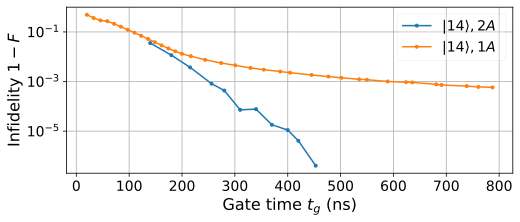

: 

In [53]:
fig, ax = plt.subplots(figsize=(8,3))
# plt.plot(np.array(drive_param_1A_n1)[:,1], Infidelity_1A_n1, 'x', label=r'1$A$, $n_{\theta 1}$')
# plt.plot(np.array(drive_param_1A_n1_x0)[:,1], Infidelity_1A_n1_x0, '.-', label=r'1$A$, $n_{\theta 1}, x_0$')
# plt.plot(np.array(drive_param_1A_n2)[:,1], Infidelity_1A_n2, '.-', label=r'1$A$, $n_{\theta 1}+n_{\theta 2}$')

# plt.plot(np.array(drive_param_2A_n1_start)[:,2], Infidelity_2A_n1_start, '.-', label=r'2$A$, $n_{\theta 1}$')
# plt.plot(np.array(drive_param_2A_n1)[:,2], Infidelity_2A_n1[:], '.-', label=r'2$A$, $n_{\theta 1}, x_0$')
plt.plot(np.array(drive_param_14_2A_combine)[:,2], Infidelity_14_2A_combine, '.-', label=r'$|14\rangle, 2A$')
# plt.plot(np.array(drive_param_2A_n1_r2)[:,2], Infidelity_2A_n1_r2, '.-', label=r'2$A$, $n_{\theta 1}, r2$')
# plt.plot(np.array(drive_param_2A_n1_x0)[:,2], Infidelity_2A_n1_x0, '+', label=r'2$A$, $n_{\theta 1}, x_0$')
# plt.plot(np.array(drive_param_2A_n1_logF)[:,2], Infidelity_2A_n1_logF, '.-', label=r'2$A$, $n_{\theta 1}, log$')
# plt.plot(np.array(drive_param_2A_n1_x0_logF)[:,2], Infidelity_2A_n1_x0_logF, '.-', label=r'2$A$, $n_{\theta 1}, x_0, log$')
plt.plot(np.array(drive_param_14_1A_combine)[:,1], Infidelity_14_1A_combine, '.-', label=r'$|14\rangle, 1A$ ')

# plt.plot(np.array(drive_param_2A_n2)[:,2], Infidelity_2A_n2, '.-', label=r'2$A$, $n_{\theta 1}+n_{\theta 2}$')
plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)')
plt.ylabel('Infidelity $1-F$')
plt.grid()
legend = plt.legend(loc='best')
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent
# plt.savefig('cnot_fidelity_2A0_and_1A0.png',dpi=300,bbox_inches='tight')

In [21]:
aa = [np.round(infidelity_2A_n1_x0_logF[i], 3) for i in range(len(infidelity_2A_n1_x0_logF))]
# [np.round(1-10**(infidelity_2A_n1_x0_logF[i]), 6) for i in range(len(infidelity_2A_n1_x0_logF))]
np.array(aa)

array([-4.265, -5.39 , -4.206, -4.783, -4.746, -4.922, -5.065, -4.742,
       -5.204, -4.68 , -5.158, -5.585, -5.016, -4.84 ])

In [22]:
param_log = [np.round(drive_param_2A_n1_x0_logF[i], 5) for i in range(len(infidelity_2A_n1_x0_logF))]
# qt.Qobj(param_log)
np.array(param_log)

array([[ 8.5200000e-02,  2.8760000e-02,  4.0400207e+02, -2.5980000e-02,
        -3.4010000e-02],
       [ 7.3680000e-02,  1.6810000e-02,  4.2013379e+02, -1.6490000e-02,
        -2.9710000e-02],
       [ 1.9850000e-02,  4.6440000e-02,  4.5294357e+02, -3.2210000e-02,
        -2.6570000e-02],
       [ 7.5690000e-02,  1.6290000e-02,  4.7681200e+02, -2.1140000e-02,
        -3.2360000e-02],
       [ 8.4080000e-02,  1.7790000e-02,  5.0821635e+02, -3.1660000e-02,
        -4.1220000e-02],
       [ 7.4690000e-02,  2.2740000e-02,  5.2053574e+02, -2.0200000e-02,
        -2.6670000e-02],
       [ 1.9260000e-02,  4.9760000e-02,  5.6162497e+02, -3.8310000e-02,
        -3.2700000e-02],
       [ 9.1120000e-02,  2.0680000e-02,  5.6820580e+02, -2.0450000e-02,
        -3.5720000e-02],
       [ 1.5780000e-02,  5.7380000e-02,  6.2296234e+02, -4.4960000e-02,
        -3.5020000e-02],
       [ 8.8310000e-02,  1.9210000e-02,  6.4995359e+02, -2.3110000e-02,
        -3.5070000e-02],
       [ 2.1140000e-02,  5.967

In [23]:
[-1+10**(infidelity_2A_n1_x0_logF[i]) for i in range(len(infidelity_2A_n1_x0_logF))]


[-0.9999456450542921,
 -0.999995930274163,
 -0.9999377891704537,
 -0.9999835210175945,
 -0.9999820654493886,
 -0.9999880215580467,
 -0.9999913808128518,
 -0.9999818811826582,
 -0.9999937482528842,
 -0.9999790841006808,
 -0.9999930545836826,
 -0.9999974028093327,
 -0.9999903543110971,
 -0.9999855379284052]

# $|45\rangle$

In [24]:
fidelity_45_1A =  [-0.9629947374533175, -0.9750972956447546, -0.9819652381352315, -0.9881411097696902,
-0.9912096239339668, -0.9929164980649698, -0.993785196543182, -0.9946780327392659,
-0.9964485575312187, -0.9893382786862641, -0.9928731967078865, -0.9949261499733636,
-0.9983844178115027, -0.9967045804977331, -0.9971646067266468, -0.9992049132818164,
-0.9992479137991165, -0.9988691192678292, -0.9989474416301551, -0.9991364388607265,
-0.9993745757351874, -0.9992840408084682, -0.9993950266270171, -0.9993105876220991, -0.9993343188753453]
Infidelity_45_1A = 1+np.array(fidelity_45_1A)

drive_param_45_1A =  [[0.03316051547028448, 127.99039231450664, -0.20606921301666467],
[0.02642552742394146, 155.99735471662026, -0.2008730011374458],
[0.03672904921007919, 183.99805723397404, -0.19745773290203525],
[0.03179743306908961, 211.9960627979209, -0.1951532816945556],
[0.02792715716831786, 239.99550004040543, -0.19369048086810367],
[0.02506841368127848, 267.99494252615415, -0.192849156487049],
[0.022737806896246583, 295.99447666508905, -0.19228424256903384],
[0.027040281447472735, 323.9903769226368, -0.1901997564985621],
[0.024926337766449747, 351.99651573835115, -0.1898880502157565],
[0.021310523983261342, 379.99977205317765, -0.004924999782094652],
[0.019784505812145897, 407.99418699057065, -0.004289332659600353],
[0.018451871746691086, 435.9937859554283, -0.0037556339153188845],
[0.01888327823393882, 463.99874695422653, -0.18942975303635368],
[0.015777011238828617, 491.9954958557246, -0.0027292698517688008],
[0.014698777705061361, 519.9954204619211, -0.0023536082641699985],
[0.01906924266587336, 547.9927697293509, -0.18803742357383932],
[0.018110172529874187, 575.9913885074701, -0.18805907815810993],
[0.01710809553620019, 603.9935831599764, -0.18806433216681362],
[0.018579113862398633, 631.9959470470325, -0.1870438529536167],
[0.017727044352374398, 659.9947519983747, -0.18703908664160512],
[0.016963654594797963, 687.9917864189766, -0.18718159602271195],
[0.0164199510793788, 715.9945989807834, -0.18738237387020668],
[0.015731461750616522, 743.9957767996373, -0.1874638467806971],
[0.014969487956156612, 771.9928978500628, -0.18754910791750423],
[0.015885646805416938, 799.998000518443, -0.18658178026110459]]

fidelity_45_2A =  [-0.9944416641300482, -0.9917146105613497,  -0.987016478035979, -0.9939881917152513]
fidelity_45_2A_x0 =  [-0.9944416641300482, -0.9986441099199714, -0.9993383930092967, -0.9980797401566693]
drive_param_45_2A =  [[0.07147926401155362, 0.06100583811959686, 127.08123690055425, -0.2620284973424872, -0.2580197137928305],
[0.06915686057871753, 0.06435309533412228, 179.5743125073848, -0.23937864707956596, -0.23609013855885397],
[0.0806281640225374, 0.09763959707498258, 259.33127052495865, -0.12066142673215897, -0.10915664588458035],
[0.09247706154602864, 0.051771136401803, 296.3737525007883, -0.05225893099039597, -0.05503572322892099]]
Infidelity_45_2A = 1+np.array(fidelity_45_2A)
Infidelity_45_2A_x0 = 1+np.array(fidelity_45_2A_x0)

In [25]:
fidelity_45_2A_tg20 =  [-0.3275708120411501, -0.40677984768893705, -0.6553425041054183,
-0.8684089592250834, -1.1504818537190125,-1.5103278101077502,  -1.72623,
-2.1169463782708764, -2.2837538953371133, -2.10131,-1.2426815176853503,
-1.4505178100489904, -3.3206190233636392, -1.6009618468413203, -1.6675815915152072]
drive_param_45_2A_tg20 =  [[0.2937827074094986, 0.20716334517023793, 19.999999995554614, -0.29985346338788776, -0.2810489670564227],
[0.10241089479179045, 0.06657146402863781, 32.85714285436836, -0.2462594563490309, -0.24266678967744326],
[0.09287652451928688, 0.061844282528780575, 45.71428571274179, -0.2451981804328725, -0.24228288097087214],
[0.0819633839079435, 0.05831298445446166, 58.57142856579773, -0.24299948279462152, -0.23999687056851765],
[0.08771058899123453, 0.06686043048119122, 71.42857142055747, -0.26245648784041775, -0.25872289932942755],

[0.0801041189074392, 0.06295752074291067, 84.28571428554989, -0.2579714639254799, -0.2543572915116533],
[0.13983228791548039, 0.12798854082621794, 97.14285713489781, -0.19243161939360756, -0.1835945911269467],
[0.07457781167872617, 0.06346544364160163, 109.99999999900716, -0.2634629366012341, -0.25926915494277636],
[0.07167743528810211, 0.06109928816714061, 122.85714285453055, -0.26147399950814865, -0.25756381463302325],
[0.12083369502514277, 0.10805662480462044, 135.714285707008, -0.15641067727071517, -0.1410672734660711],

[0.11378070699556589, 0.10621660369823538, 148.57142856532306, -0.14852863961709353, -0.13454275436860283],
[0.11998312616302251, 0.10943279347805836, 161.42857142718734, -0.16261487994573556, -0.14848056696839515],
[0.13659946069124618, 0.034396174967731535, 174.28571427594133, -0.265980086444273, -0.2791332546137629],
[0.15895473139364275, 0.09246096135475615, 187.14285713828065, -0.1522811301538221, -0.15942596214176985],
[0.17740230896165765, 0.08073493055731411, 199.99999999884747, -0.1440099599643176, -0.15624423251775954]]
Infidelity_45_2A_tg20 = [10**(fidelity_45_2A_tg20[i]) for i in range(len(fidelity_45_2A_tg20))]

In [26]:
fidelity_45_1A_tg20 =  [-0.28700771815538834, -0.36673519976530283, -0.5574591548841398,
-0.7153026053279962, -0.8448676408156841, -0.9666283935428339, -1.0029835522764765,
-1.2340022786038591, -1.4044078468898265, -1.457983194208172, -1.5499123928055778,
-1.6322290345289208, -1.668847043992898, -1.7704689337792752, -1.8556037776735703]
drive_param_45_1A_tg20 =  [[0.23304264822054793, 19.999997129222958, -0.2999376576562004],
[0.07587163786523947, 32.857139167618385, -0.24406692231805796],
[0.06896467066123327, 45.71428388590788, -0.24147682270683746],
[0.06242699612642723, 58.57142564364029, -0.23796426082145017],
[0.06934225198370643, 71.4285655628294, -0.2551786665050999],
[0.06500632939458419, 84.2857093005474, -0.2518550542379636],
[0.061486121781996986, 97.14285206829705, -0.2494027652861192],
[0.036174711865426395, 109.99999817703637, -0.20704430570097795],
[0.034054888378201614, 122.85714194831274, -0.2064834431205662],
[0.030582919763519123, 135.7142815388296, -0.2038305943062248],
[0.02769185465648903, 148.5714189667165, -0.20164005947409058],
[0.02562459412925068, 161.4285661612639, -0.2004129400295145],
[0.023566851694995034, 174.28570914287315, -0.19916934223177965],
[0.036056014883719886, 187.14285630723006, -0.19707150142435093],
[0.033705791481484004, 199.99999410142323, -0.19597529993492385]]
Infidelity_45_1A_tg20 = [10**(fidelity_45_1A_tg20[i]) for i in range(len(fidelity_45_1A_tg20))]

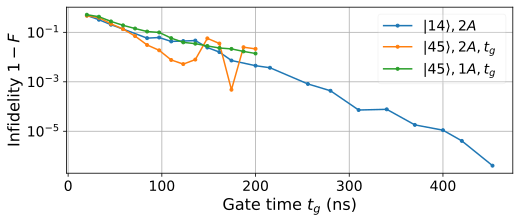

In [51]:
fig, ax = plt.subplots(figsize=(8,3))
# plt.plot(np.array(drive_param_1A_n1)[:,1], Infidelity_1A_n1, '.-', label=r'$|45\rangle, 1A$, ')
# # plt.plot(np.array(drive_param_45_1A)[:,1], Infidelity_45_1A, '.-', label=r'1$A, |45\rangle$')
# plt.plot(np.array(drive_param_45_2A)[:,2], Infidelity_45_2A, '.-', label=r'$|45\rangle, 2A$')
# plt.plot(np.array(drive_param_45_2A)[:,2], Infidelity_45_2A_x0, '.-', label=r'$|45\rangle, 2A, x_0$')
plt.plot(np.array(drive_param_2A_combine)[:,2], Infidelity_2A_combine, '.-', label=r'$|14\rangle, 2A$')
plt.plot(np.array(drive_param_45_2A_tg20)[:,2], Infidelity_45_2A_tg20, '.-', label=r'$|45\rangle, 2A, t_g$ ')
plt.plot(np.array(drive_param_45_1A_tg20)[:,1], Infidelity_45_1A_tg20, '.-', label=r'$|45\rangle, 1A, t_g$ ')

plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)')
plt.ylabel('Infidelity $1-F$')
plt.grid()
legend = plt.legend(loc='best')
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

# plt.savefig('cnot_fidelity_2A0_and_1A0.png',dpi=300,bbox_inches='tight')

## tg=20-200

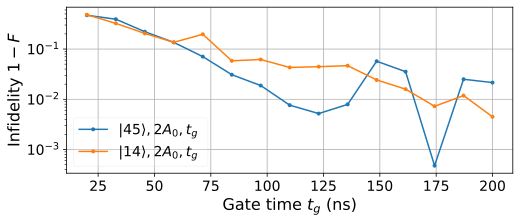

In [ ]:
fig, ax = plt.subplots(figsize=(8,3))
plt.plot(np.array(drive_param_45_tg20)[:,2], Infidelity_45_tg20, '.-', label=r'$|45\rangle, 2A, t_g$ ')
plt.plot(np.array(drive_param_14_tg20)[:,2], Infidelity_14_tg20, '.-', label=r'$|14\rangle, 2A, t_g$ ')

plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)')
plt.ylabel('Infidelity $1-F$')
plt.grid()
legend = plt.legend(loc='best')
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent
